# Simple Linear Regression with Synthetic Data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## 1. Generating Synthetic Data

We will create a simple dataset where `Salary` is roughly proportional to `YearsExperience` plus some random noise.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 50 data points
n_samples = 50

# Years of Experience (0 to 10 years)
years = np.random.rand(n_samples) * 10

# Base Salary 30k + 5k per year of experience + Random Noise
salary = 30000 + (years * 5000) + (np.random.randn(n_samples) * 3000)

# Create DataFrame
df = pd.DataFrame({
    'YearsExperience': years,
    'Salary': salary
})

# Display first few rows
df.head()


,YearsExperience,Salary
0,3.745401,50942.405682
1,9.507143,78049.820164
2,7.319939,66252.752243
3,5.986585,59029.613123
4,1.560186,33365.366051


## 2. Visualizing the Data

Before training, let's plot the data to see the relationship.


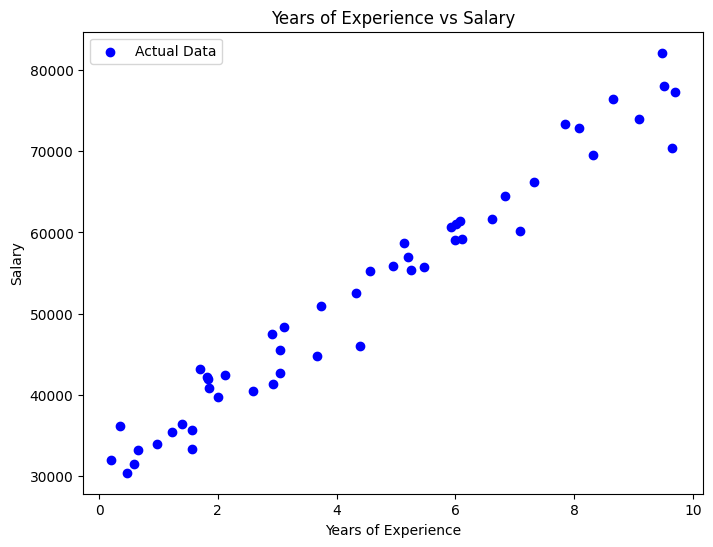

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(df['YearsExperience'], df['Salary'], color='blue', label='Actual Data')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()


## 3. Training the Linear Regression Model

We will use `scikit-learn`'s `LinearRegression` model. We need to reshape our input `X` to be a 2D array.


In [4]:
# Prepare Data
X = df[['YearsExperience']]  # Feature (2D array)
y = df['Salary']             # Target (1D array)

# Initialize and Fit Model
model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")


Intercept: 30290.07
Coefficient (Slope): 4932.97


## 4. Visualizing the Regression Line

Now let's plot the regression line (predictions) on top of our original data.


d:\Reality_AI\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


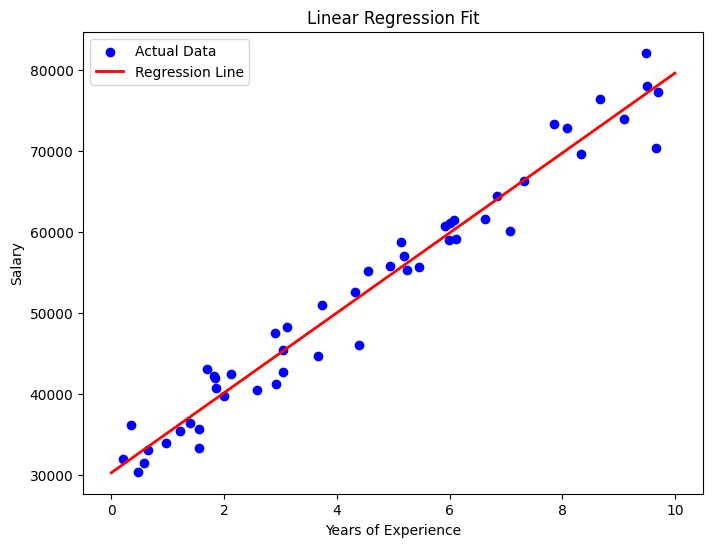

In [5]:
# Make predictions for the entire range of X
X_range = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred_line = model.predict(X_range)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(df['YearsExperience'], df['Salary'], color='blue', label='Actual Data')
plt.plot(X_range, y_pred_line, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression Fit')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()
